In [ ]:
#Name : Mark Waako
#Student ID: 112107263
import pandas as pd
df1= pd.read_csv("cities.csv")

#The .info() method prints a  summary of the DataFrame.
# It shows the total number of rows, column names, the number of non-null values.
df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   City            128 non-null    object
 1   State           128 non-null    object
 2   failed_logins   128 non-null    int64 
 3   login_attempts  128 non-null    int64 
 4   alerts          128 non-null    object
 5   last_incident   128 non-null    object
dtypes: int64(2), object(4)
memory usage: 6.1+ KB


In [ ]:
#Name : Mark Waako
#Student ID: 112107263

df1.describe()

,failed_logins,login_attempts
count,128.000000,128.000000
mean,48.992188,150.351562
std,29.904440,43.840547
min,0.000000,51.000000
25%,21.000000,114.750000
50%,52.000000,153.000000
75%,74.250000,183.500000
max,100.000000,238.000000


Count: The total number of non-empty values in each numeric column.

Mean: The average of the values in that column.

Std: Measures how spread out the numbers are it shows the deviation means in data is highly variable or  low  close to the average.

Min: The  lowest value found in that column

Percentiles 25%: of the values are less than given value

Percentiles 50%: of the values are less than given value in table

Percentiles 75%: of the values are less than in the table

Max: The highest value found in that column data.

In [ ]:
#Name : Mark Waako
#Student ID: 112107263
df1.head()

,City,State,failed_logins,login_attempts,alerts,last_incident,failed_login_rate
0,"""Youngstown""",OH,51,172,High,2025-08-30 23:23,0.296512
1,"""Yankton""",SD,92,153,High,2025-03-11 7:40,0.601307
2,"""Yakima""",WA,14,97,Low,2025-12-28 16:48,0.144330
3,"""Worcester""",MA,71,153,High,2025-09-21 7:19,0.464052
4,"""Wisconsin Dells""",WI,60,157,High,2025-03-03 14:28,0.382166


In [ ]:
df1.tail()

,City,State,failed_logins,login_attempts,alerts,last_incident,failed_login_rate
123,"""Reno""",NV,4,122,Low,2025-08-13 1:16,0.032787
124,"""Regina""",SA,40,187,Medium,2025-07-21 3:45,0.213904
125,"""Red Bluff""",CA,27,146,Medium,2025-11-18 19:59,0.184932
126,"""Reading""",PA,6,141,Low,2025-12-21 15:44,0.042553
127,"""Ravenna""",OH,72,132,High,2025-04-07 20:58,0.545455


In [ ]:

df1.shape
print(f"The ratio of rows to colomns is: {df1.shape}")
#128 rows and 6 colomns

The ratio of rows to colomns is: (128, 7)


In [ ]:
#Name : Mark Waako
#Student ID: 112107263
high_risk_cities = df1[df1["failed_logins"] > 50]
print(high_risk_cities)

                   City State  failed_logins  login_attempts alerts  \
0          "Youngstown"    OH             51             172   High   
1             "Yankton"    SD             92             153   High   
3           "Worcester"    MA             71             153   High   
4     "Wisconsin Dells"    WI             60             157   High   
6            "Winnipeg"    MB             82             193   High   
..                  ...   ...            ...             ...    ...   
112           "Roswell"    NM             87             226   High   
115          "Rockford"    IL             87             168   High   
116         "Rochester"    NY             62             179   High   
118           "Roanoke"    VA             80             204   High   
127           "Ravenna"   OH              72             132   High   

        last_incident  failed_login_rate  
0    2025-08-30 23:23           0.296512  
1     2025-03-11 7:40           0.601307  
3     2025-09-21 7

In [ ]:
#Name : Mark Waako
#Student ID: 112107263

high_risk_cities_sorted = high_risk_cities.sort_values(by='failed_logins', ascending=False)

In [ ]:
city_count = len(high_risk_cities_sorted)
print(f"\nTotal number of high-risk cities: {city_count}")


Total number of high-risk cities: 66


Sorting and counting the data gives a speficic count for  understanding of the scope of the threat.

becuse of the large amounts of data SOC analysts have to deal with sorting data in this way helps them prioretize critical systems.


In [ ]:
#Name : Mark Waako
#Student ID: 112107263

cities_per_state = df1.groupby("State")["City"].count()
print(cities_per_state)

State
AL      2
AZ      1
BC      1
CA     12
CO      3
CT      1
DC      1
DE      1
FL      5
GA      4
IA      2
ID      1
IL      3
IN      4
KS      3
LA      1
MA      2
MB      1
MD      1
MI      4
MN      3
MO      4
MS      2
NB      1
NC      3
ND      2
NJ      1
NM      2
NV      1
NY      5
OH      5
OH      1
OK      2
ON      1
OR      1
PA      6
SA      1
SC      1
SD      3
TX      8
UT      2
VA      4
VT      2
WA      6
WI      4
WV      2
WY      2
Name: City, dtype: int64


In [ ]:
highest_state = cities_per_state.idxmax()
print(f"The state with the highest number of cities is: {highest_state}")

The state with the highest number of cities is:  CA


In [ ]:
#Name : Mark Waako
#Student ID: 112107263

cities_per_state = df1.groupby("State")["City"].count()
print((cities_per_state.sort_values(ascending=False)).head())

State
CA    12
TX     8
PA     6
WA     6
OH     5
Name: City, dtype: int64


The .idxmax() method looks through returns the index label with  the highest value. it picks out the maximum value of associated with row.

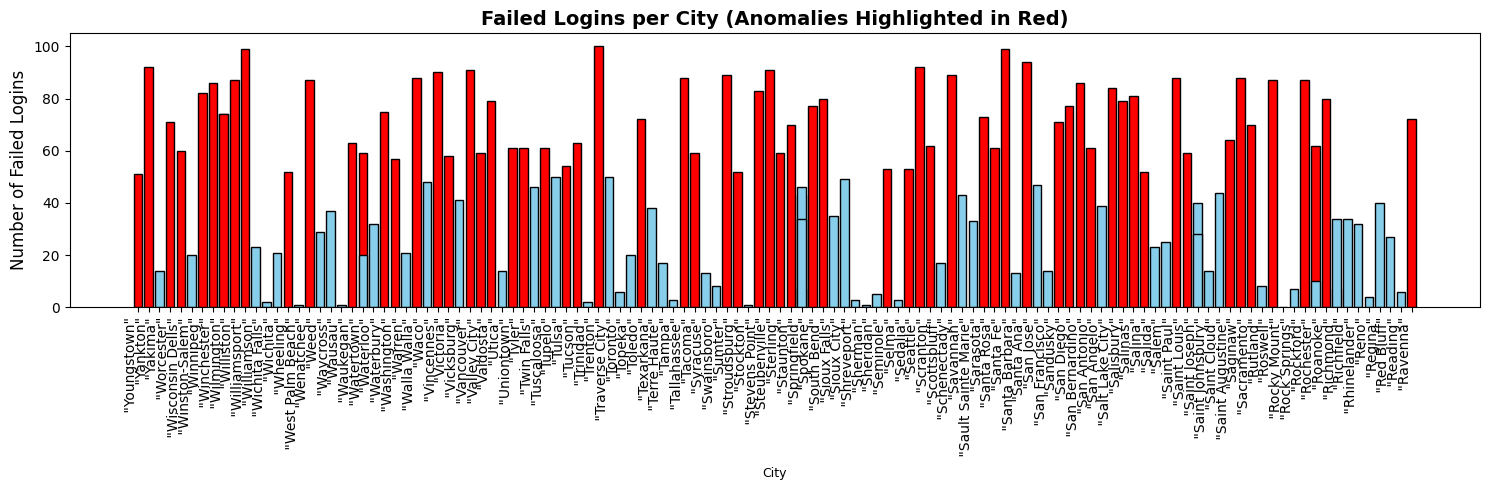

In [ ]:
from numpy import spacing
# Name: Mark Waako
# Student ID: 112107263

import matplotlib.pyplot as plt

#Define colors dynamically based on the threshold (> 50 failed logins)
#High-risk cities will be red, normal cities will be skyblue
colors = ['red' if x > 50 else 'skyblue' for x in df1['failed_logins']]

plt.figure(figsize=(15, 5))
plt.bar(df1['City'], df1['failed_logins'], color=colors, edgecolor='black',width=0.8)


plt.title('Failed Logins per City (Anomalies Highlighted in Red)', fontsize=14, fontweight='bold')
plt.xlabel('City', fontsize=9)
plt.ylabel('Number of Failed Logins', fontsize=12)

plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
#Name: Mark Waako
# Student ID: 112107263





instead of reeading through sheets of sturctured data from top to booom that wouldtake hours visualsation helps the analyst to pinpoint what dataof what cities to look at.

It helps the analyst to focus on more critical systems and infrusturcuture.

In [ ]:


#Name: Mark Waako
# Student ID: 112107263
# new entry in df1 is ['failed_login_rate']numof failded logins over login attempts
df1['failed_login_rate'] = df1['failed_logins'] / df1['login_attempts']
display(df1)

,City,State,failed_logins,login_attempts,alerts,last_incident,failed_login_rate
0,"""Youngstown""",OH,51,172,High,2025-08-30 23:23,0.296512
1,"""Yankton""",SD,92,153,High,2025-03-11 7:40,0.601307
2,"""Yakima""",WA,14,97,Low,2025-12-28 16:48,0.144330
3,"""Worcester""",MA,71,153,High,2025-09-21 7:19,0.464052
4,"""Wisconsin Dells""",WI,60,157,High,2025-03-03 14:28,0.382166
...,...,...,...,...,...,...,...
123,"""Reno""",NV,4,122,Low,2025-08-13 1:16,0.032787
124,"""Regina""",SA,40,187,Medium,2025-07-21 3:45,0.213904
125,"""Red Bluff""",CA,27,146,Medium,2025-11-18 19:59,0.184932
126,"""Reading""",PA,6,141,Low,2025-12-21 15:44,0.042553


In [ ]:
df1_sorted_by_rate = df1.sort_values(by='failed_login_rate', ascending=False)
print("Top 5 Cities by Failed Login Rate:")
display(df1_sorted_by_rate.head(5))

Top 5 Cities by Failed Login Rate:


,City,State,failed_logins,login_attempts,alerts,last_incident,failed_login_rate
109,"""Saginaw""",MI,88,139,High,2025-05-26 18:58,0.633094
93,"""San Bernardino""",CA,86,137,High,2025-11-29 6:58,0.627737
1,"""Yankton""",SD,92,153,High,2025-03-11 7:40,0.601307
25,"""Waterbury""",CT,75,133,High,2025-06-23 4:39,0.563910
45,"""Trenton""",NJ,100,181,High,2025-05-01 5:05,0.552486


By usimg two forms of data from a given dataframe it cuts down on inaccuracies and gives a specific analysis. like two forms of data put into one for the rate of logins. While the failed login number if not put in relation with another it could be just give a number without seeing whats really critical.   